## **Data Describtion**

1) Airline: The name of the airline company is stored in the airline column. It is a categorical feature having 6 different airlines.

2) Flight: Flight stores information regarding the plane's flight code. It is a categorical feature.

3) Source City: City from which the flight takes off. It is a categorical feature having 6 unique cities.

4) Departure Time: This is a derived categorical feature obtained created by grouping time periods into bins. It stores information about the departure time and have 6 unique time labels.

5) Stops: A categorical feature with 3 distinct values that stores the number of stops between the source and destination cities.

6) Arrival Time: This is a derived categorical feature created by grouping time intervals into bins. It has six distinct time labels and keeps information about the arrival time.

7) Destination City: City where the flight will land. It is a categorical feature having 6 unique cities.

8) Class: A categorical feature that contains information on seat class; it has two distinct values: Business and Economy.

9) Duration: A continuous feature that displays the overall amount of time it takes to travel between cities in hours.

10) Days Left: This is a derived characteristic that is calculated by subtracting the trip date by the booking date.

11) Price: Target variable stores information of the ticket price.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/airlines_flights_data.csv")
df.drop("index", axis=1, inplace=True)

df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,300153.0,12.221021,7.191997,0.83,6.83,11.25,16.17,49.83
days_left,300153.0,26.004751,13.561004,1.00,15.00,26.00,38.00,49.00
price,300153.0,20889.660523,22697.767366,1105.00,4783.00,7425.00,42521.00,123071.00


In [5]:
df.isna().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

##### Showing all the Airlines with their number of flights in Horizontal Bar Graph

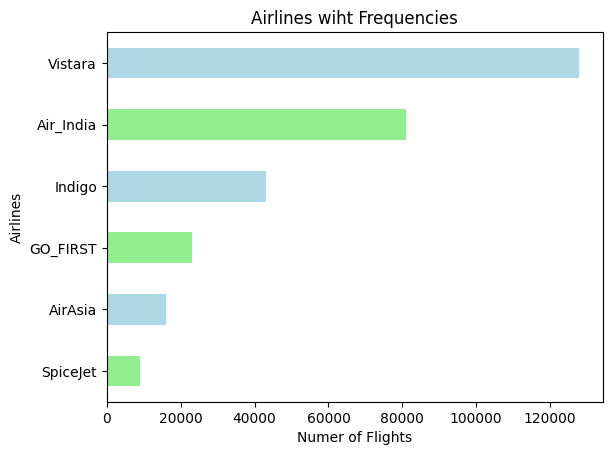

In [6]:
df["airline"].value_counts(ascending=True).plot.barh(color = ["lightgreen", "lightblue"])
plt.title("Airlines wiht Frequencies")
plt.xlabel("Numer of Flights")
plt.ylabel("Airlines")
plt.show()

##### Show Bar Graphs representing the Departure Time & Arrival Time

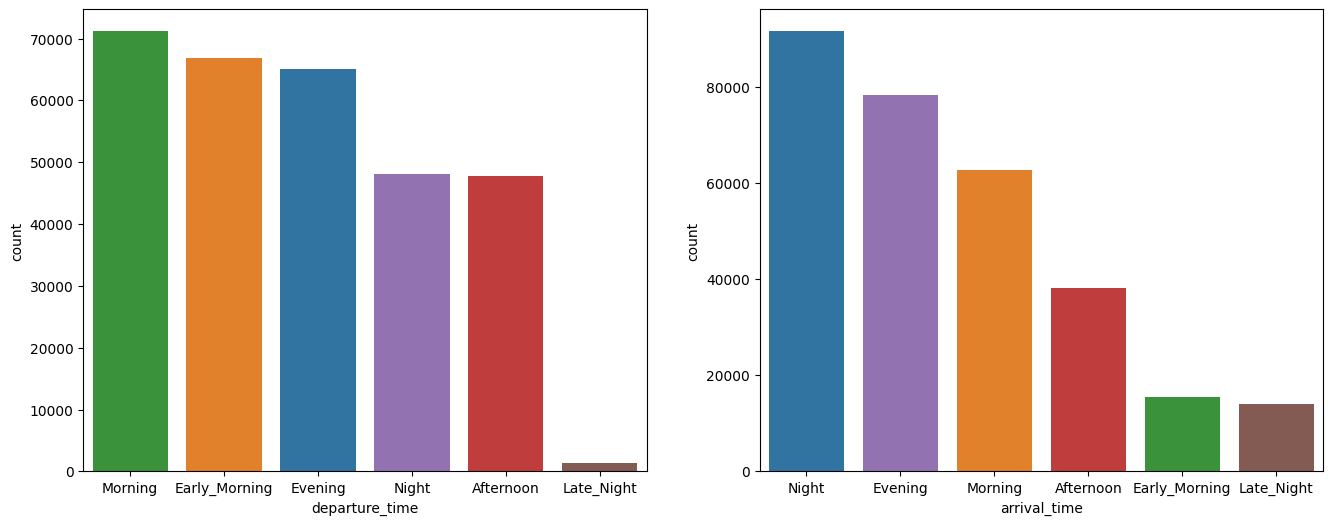

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
deprature_time_indcies = df["departure_time"].value_counts().index
arrival_time_indcies = df["arrival_time"].value_counts().index
sns.countplot(data=df, x="departure_time", ax=ax[0], order=deprature_time_indcies, hue="departure_time")
sns.countplot(data=df, x="arrival_time", ax=ax[1], order=arrival_time_indcies, hue="arrival_time")
plt.show()

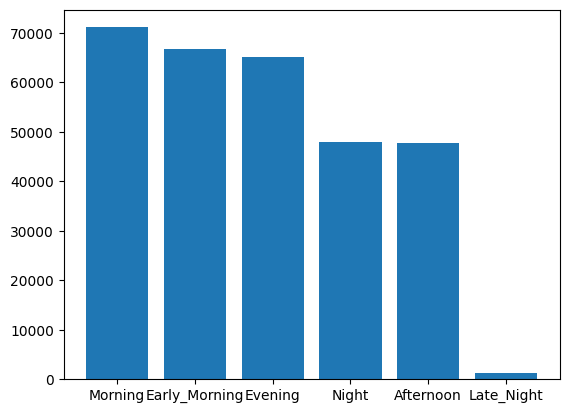

In [8]:
plt.bar(df["departure_time"].value_counts().index, df["departure_time"].value_counts())
plt.show()

##### Show Bar Graphs representing the Source City & Destination City

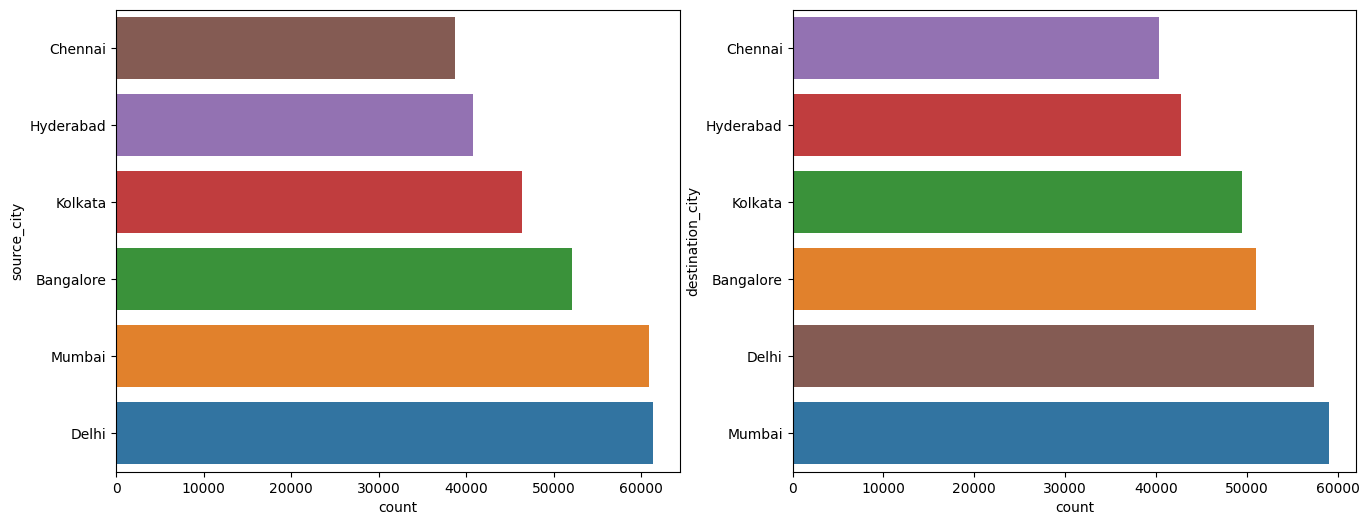

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(data=df, y="source_city", hue="source_city", ax=ax[0], order=df["source_city"].value_counts(ascending=True).index)
sns.countplot(data=df, y="destination_city", hue="destination_city", ax=ax[1], order=df["destination_city"].value_counts(ascending=True).index)
plt.show()

##### Does price varies with airlines

In [10]:
airlines_price = df.groupby("airline")["price"].agg("mean").sort_values()
print(airlines_price)

airline
AirAsia       4091.072742
Indigo        5324.216303
GO_FIRST      5652.007595
SpiceJet      6179.278881
Air_India    23507.019112
Vistara      30396.536302
Name: price, dtype: float64


##### Drawing a Categorical Plot showing the Mean Ticket Price for each Airline

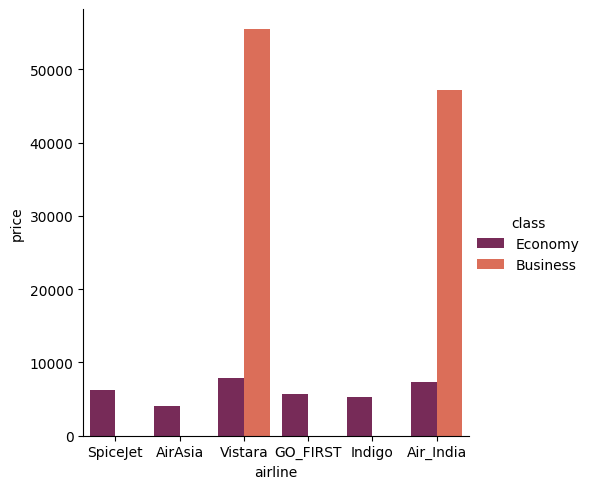

In [11]:
sns.catplot(x="airline", y="price", data=df, kind="bar", hue="class", errorbar=None, palette="rocket")
plt.show()

##### Does ticket price change based on the departure time and arrival time

In [12]:
departure_time_price = df.groupby("departure_time")["price"].mean()
arrival_time_price = df.groupby("arrival_time")["price"].mean()
print(departure_time_price)
print(arrival_time_price)

departure_time
Afternoon        18179.203331
Early_Morning    20370.676718
Evening          21232.361894
Late_Night        9295.299387
Morning          21630.760254
Night            23062.146808
Name: price, dtype: float64
arrival_time
Afternoon        18494.598993
Early_Morning    14993.139521
Evening          23044.371615
Late_Night       11284.906078
Morning          22231.076098
Night            21586.758341
Name: price, dtype: float64


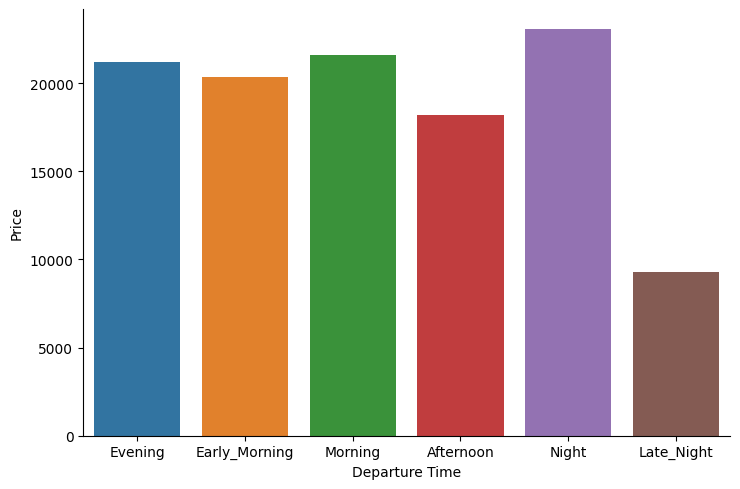

In [13]:
sns.catplot(data=df, x="departure_time", y="price", kind="bar", aspect=1.5, hue="departure_time", errorbar=None)
plt.xlabel("Departure Time")
plt.ylabel("Price")
plt.show()

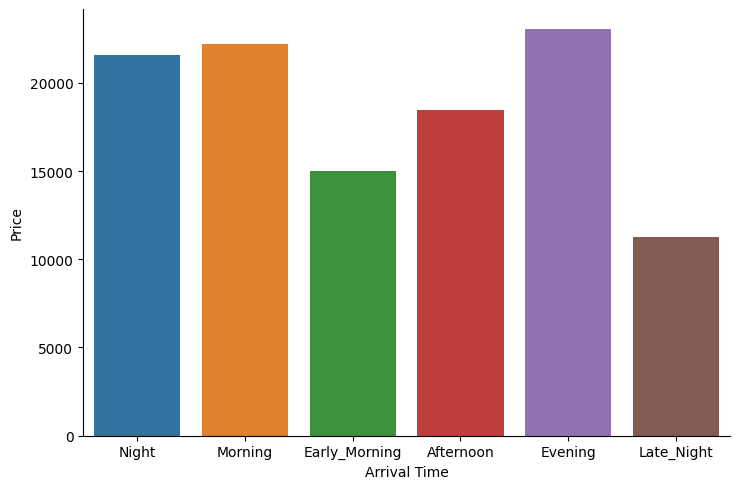

In [14]:
sns.catplot(data=df, x="arrival_time", y="price", kind="bar", aspect=1.5, hue="arrival_time", errorbar=None)
plt.xlabel("Arrival Time")
plt.ylabel("Price")
plt.show()

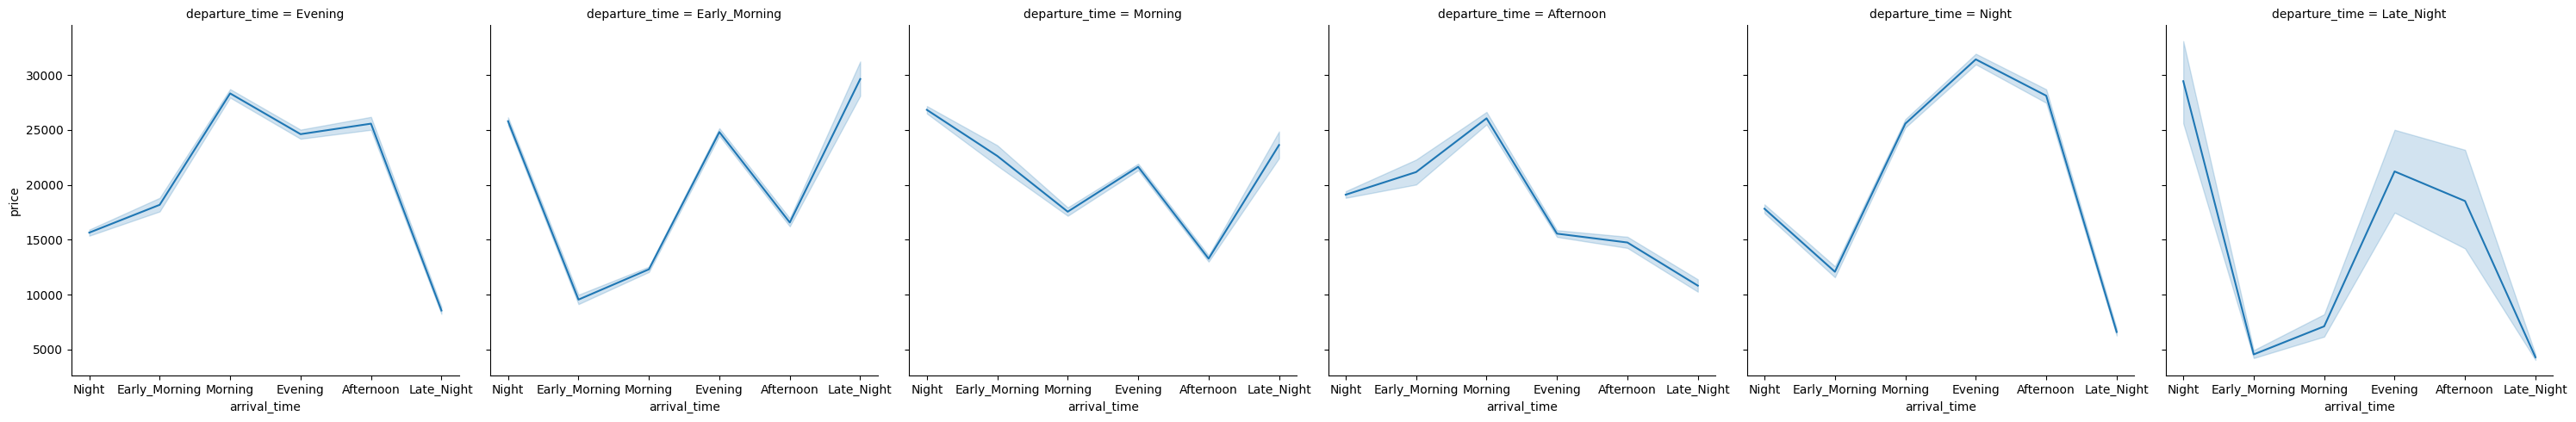

In [15]:
sns.relplot(x="arrival_time", y="price", data=df, col="departure_time", kind="line")
plt.show()

##### How the price changes with change in Source and Destination

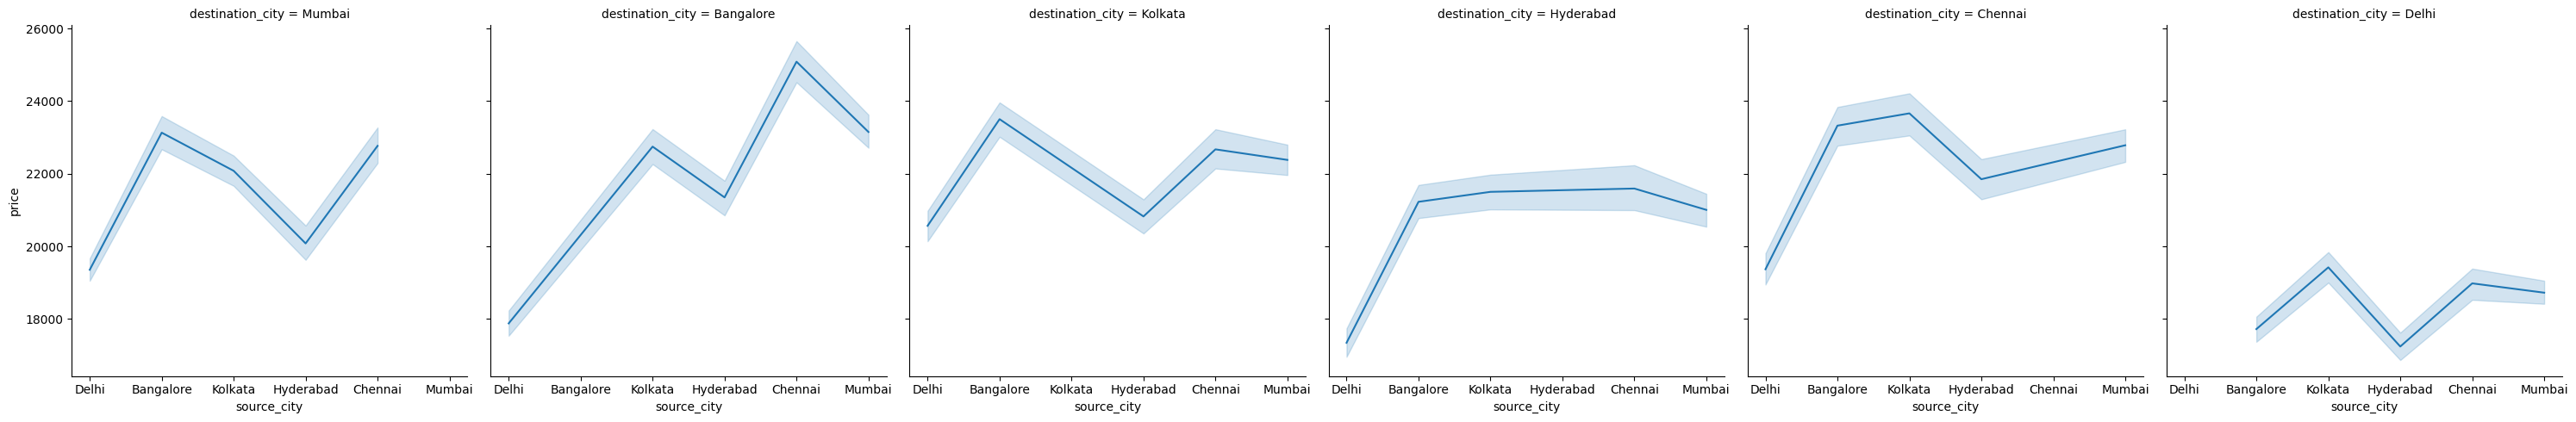

In [16]:
sns.relplot(data=df, x="source_city", y="price", col="destination_city", kind="line")
plt.show()

##### How is the price affected when tickets are bought in just 1 or 2 days before departure?

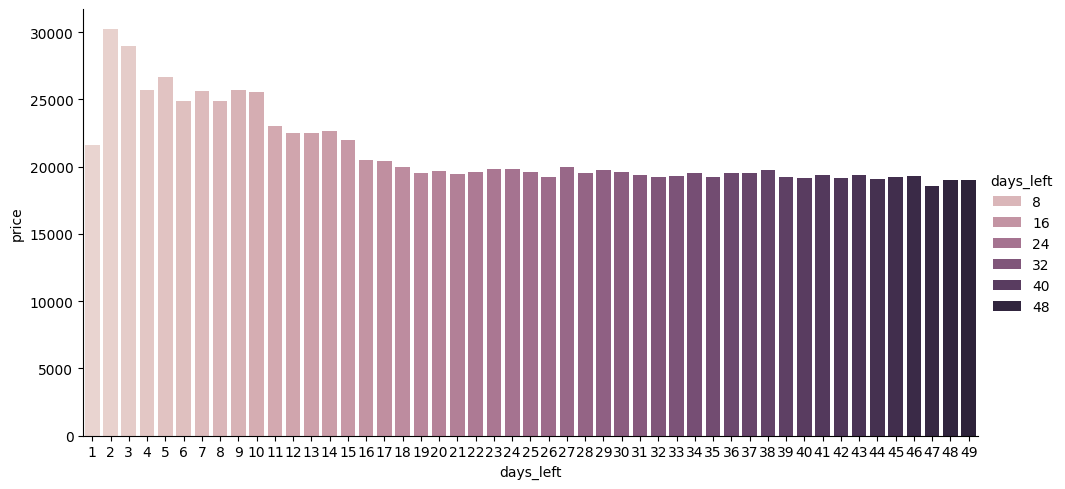

In [17]:
sns.catplot(data=df, x="days_left", y="price", kind="bar", hue="days_left", aspect=2, errorbar=None)
plt.show()

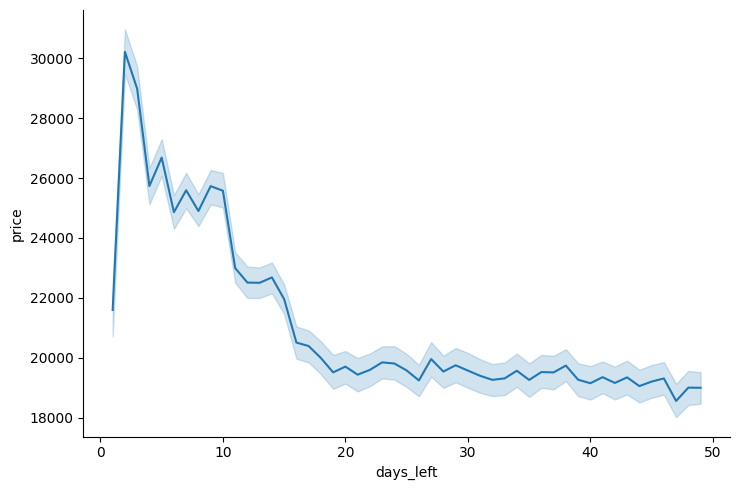

In [18]:
sns.relplot(data=df, x="days_left", y="price", kind="line", aspect=1.5)
plt.show()

##### How does the ticket price vary between Economy and Business class

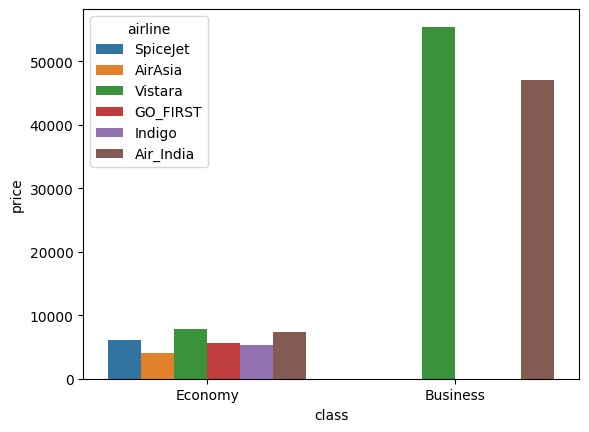

In [19]:
sns.barplot(data=df, x="class", y="price", hue="airline", errorbar=None)
plt.show()

##### What will be the Average Price of Vistara airline for a flight from Delhi to Hyderabad in Business Class ?

In [20]:
mean_price = df[
    (df["airline"] == "Vistara") & 
    (df["source_city"] == "Delhi") &
    (df["destination_city"] == "Hyderabad") &
    (df["class"] == "Business")
]["price"].mean().item()
print(mean_price)

47939.840361445786


#### Displaying the distribution of the numberical columns

In [21]:
# Building a function to display the distribution
def display_distribution(data, numerical_cols, figure_name):
    fig, ax = plt.subplots(1, len(numerical_cols), figsize=(16, 6), dpi=95)
    for i, col in enumerate(numerical_cols):
        ax[i].hist(data=data, x=col)
        ax[i].set_xlabel(col, fontsize=13)
    plt.tight_layout()
    plt.show()

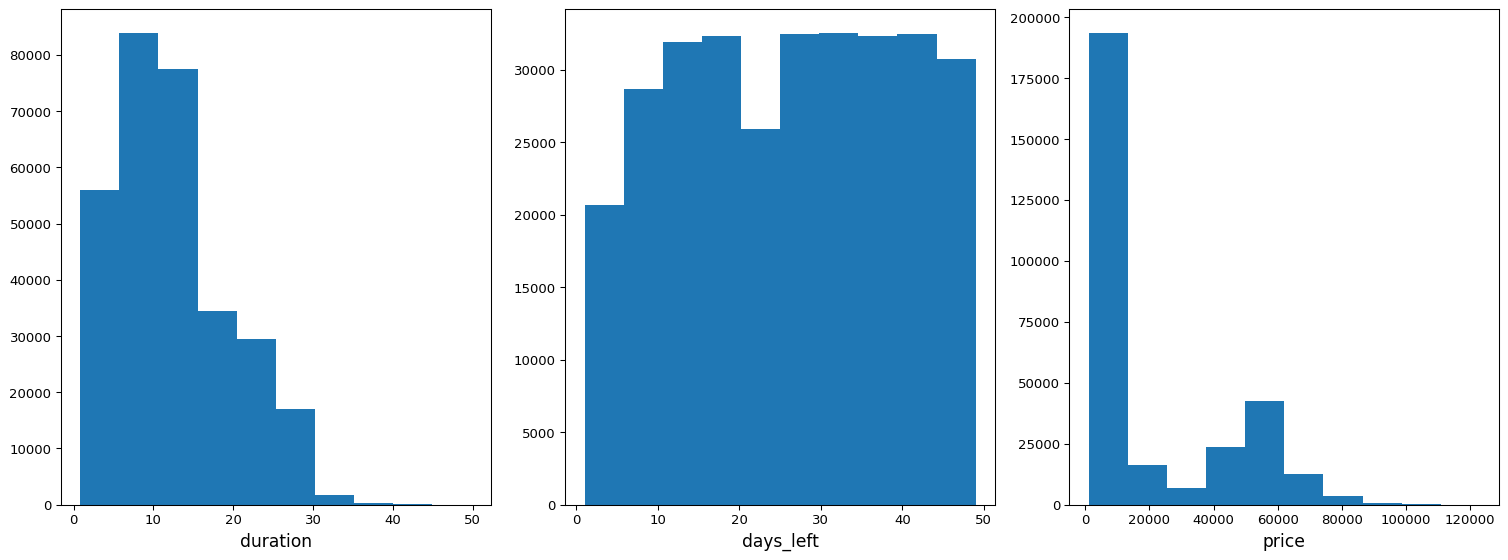

In [22]:
numerical_cols = df.select_dtypes("number").columns
display_distribution(data=df, numerical_cols=numerical_cols, figure_name="distributions")


##### Displaying Boxplots to show outliers

In [23]:
# Building a function to display outliers
def display_outilers(data, numerical_cols, figure_name):
    fig, ax = plt.subplots(len(numerical_cols), 1, figsize=(7, 18), dpi=95)
    for i, col in enumerate(numerical_cols):
        ax[i].boxplot(data[col], vert=False)
        ax[i].set_ylabel(col)
    plt.tight_layout()
    plt.show()

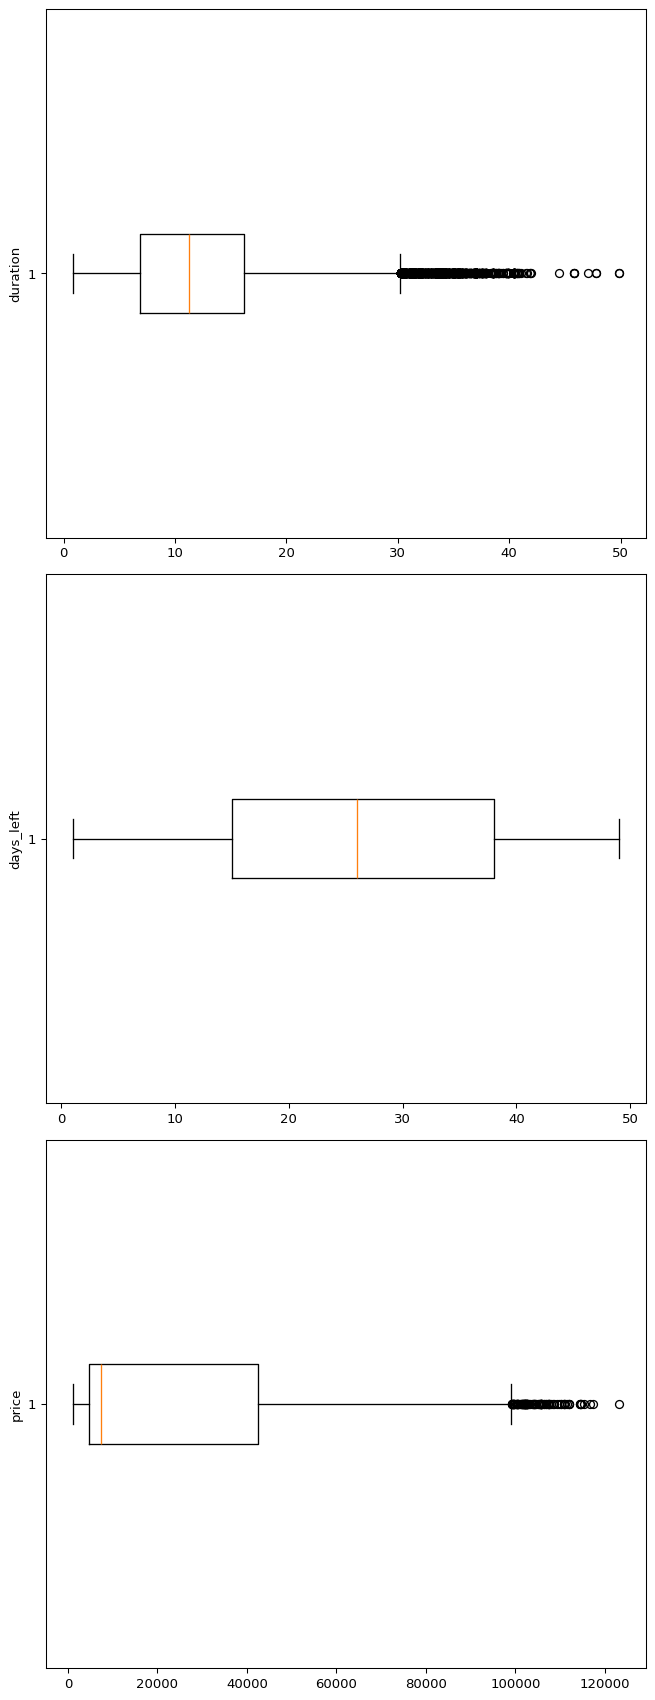

In [24]:
numerical_cols = df.select_dtypes("number").columns
display_outilers(data=df, numerical_cols=numerical_cols, figure_name="with_outliers")

##### Applying logarithimic transformation to handling the right skewing

In [25]:
right_skewed_data = ["duration", "price"]
df[right_skewed_data] = np.log1p(df[right_skewed_data])

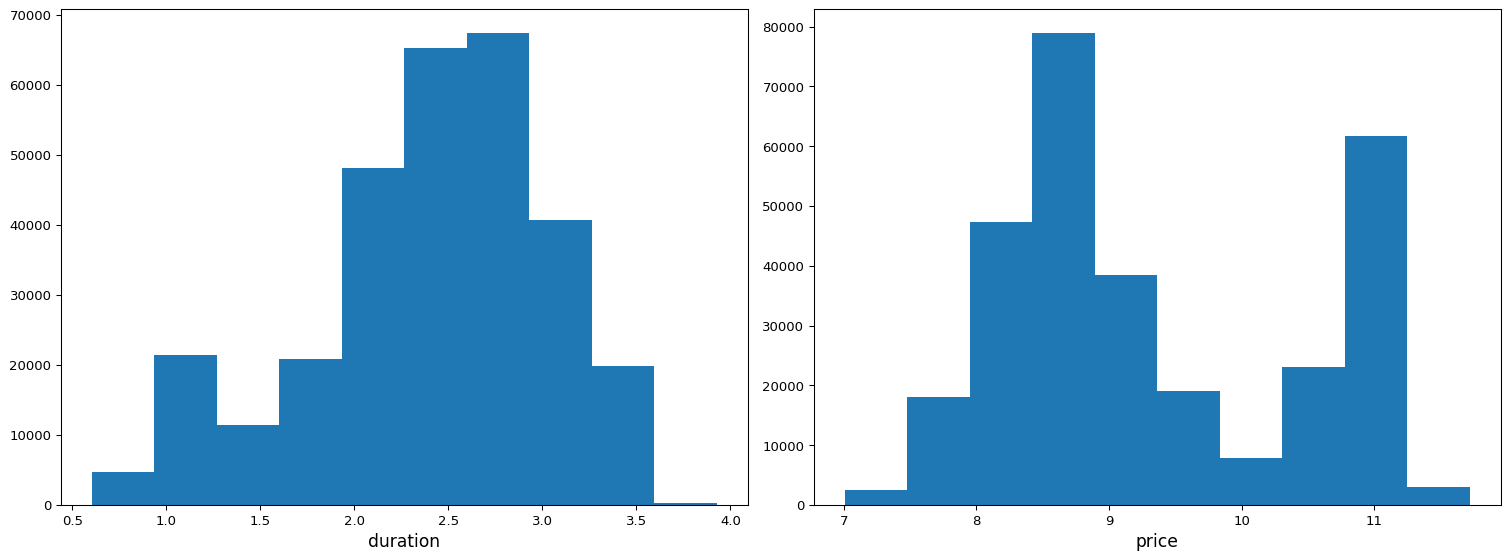

In [26]:
display_distribution(df, right_skewed_data, "distribution_after_log")

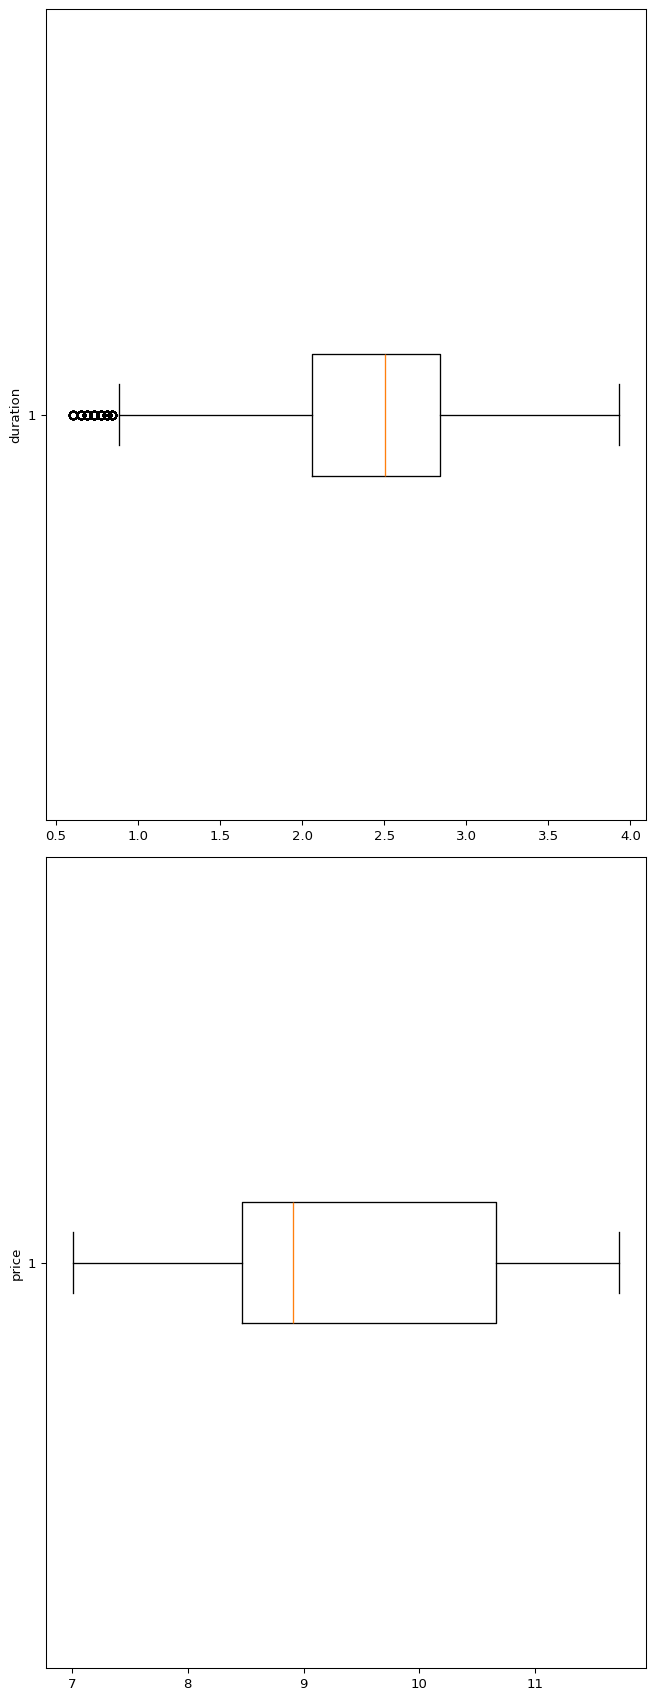

In [27]:
display_outilers(df, right_skewed_data, "outliers_after_log")

In [28]:
# Ordinal Encoding for Ordinal Features
df["stops"] = df["stops"].map({"zero": 0, "one": 1, "two_or_more": 2})
df["class"] = df["class"].map({"Economy": 0, "Business": 1})

In [ ]:
# Saving data after processing
data_ml_model = df.copy()
data_ml_model.to_csv("data/data_ml_model.csv", index=False)

## We finished Data Processing, Let's transfer to building the Machine Learning Model